<a href="https://colab.research.google.com/github/Ektatotala/store-sales-analysis/blob/main/store_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

path = kagglehub.dataset_download("surajjha101/stores-area-and-sales-data")
print(path)

100%|██████████| 9.60k/9.60k [00:00<00:00, 13.1MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/surajjha101/stores-area-and-sales-data/versions/1


In [2]:
import pandas as pd
import os

# Check files inside folder
print(os.listdir(path))

['Stores.csv']


In [4]:
df = pd.read_csv(os.path.join(path, "Stores.csv"))

df.head()

,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales
0,1,1659,1961,530,66490
1,2,1461,1752,210,39820
2,3,1340,1609,720,54010
3,4,1451,1748,620,53730
4,5,1770,2111,450,46620


In [5]:
# Basic info
df.info()

# Summary
df.describe()

# Check correlation
print(df.corr())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 896 entries, 0 to 895
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Store ID              896 non-null    int64
 1   Store_Area            896 non-null    int64
 2   Items_Available       896 non-null    int64
 3   Daily_Customer_Count  896 non-null    int64
 4   Store_Sales           896 non-null    int64
dtypes: int64(5)
memory usage: 35.1 KB
                      Store ID   Store_Area  Items_Available  \
Store ID               1.000000   -0.058705        -0.055707   
Store_Area            -0.058705    1.000000         0.998891   
Items_Available       -0.055707    0.998891         1.000000   
Daily_Customer_Count  -0.010029   -0.041423        -0.040978   
Store_Sales            0.071486    0.097474         0.098849   

                      Daily_Customer_Count  Store_Sales  
Store ID                         -0.010029     0.071486  
Store_Area   

In [7]:
# Top 5 stores by sales
print(df.sort_values(by='Store_Sales', ascending=False).head())

# Bottom 5 stores
print(df.sort_values(by='Store_Sales', ascending=True).head())

     Store ID   Store_Area  Items_Available  Daily_Customer_Count  Store_Sales
649        650        1989             2414                   860       116320
868        869        1775             2104                   980       105150
432        433        1365             1638                   680       102920
408        409        1303             1587                  1310       102310
758        759        1486             1758                   820       101820
     Store ID   Store_Area  Items_Available  Daily_Customer_Count  Store_Sales
31          32        1250             1508                   990        14920
852        853        1477             1790                   880        16370
775        776        1537             1877                   660        17670
593        594        1624             1946                   870        20270
352        353        1397             1686                   850        21300


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df.columns

Index(['Store ID ', 'Store_Area', 'Items_Available', 'Daily_Customer_Count',
       'Store_Sales'],
      dtype='object')

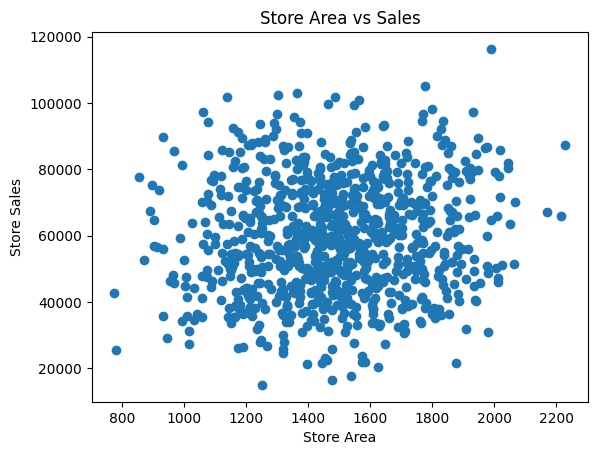

In [11]:
plt.figure()
plt.scatter(df['Store_Area'], df['Store_Sales'])
plt.xlabel("Store Area")
plt.ylabel("Store Sales")
plt.title("Store Area vs Sales")
plt.show()

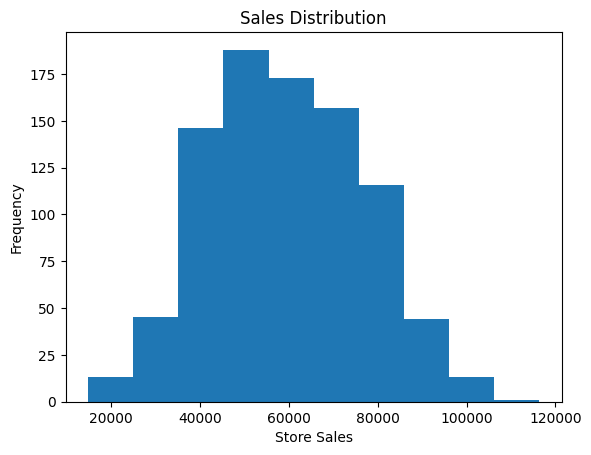

In [13]:
plt.figure()
plt.hist(df['Store_Sales'])
plt.title("Sales Distribution")
plt.xlabel("Store Sales")
plt.ylabel("Frequency")
plt.show()

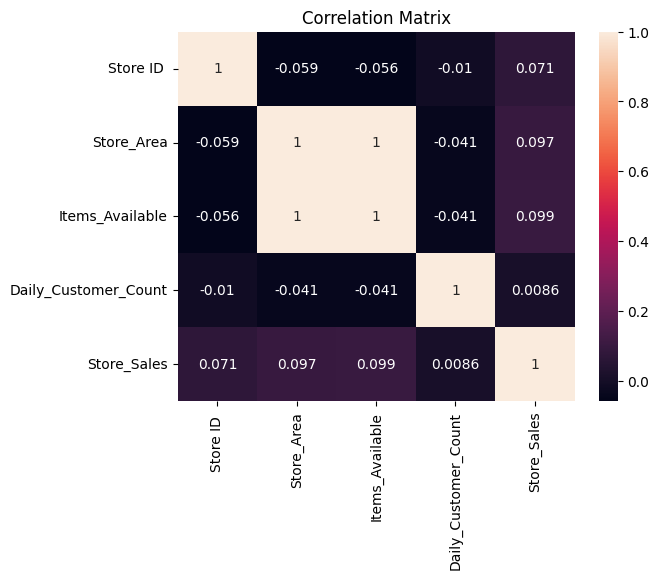

In [14]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [16]:
# Sales per unit area (efficiency)
df['Sales_per_Area'] = df['Store_Sales'] / df['Store_Area']

# Top efficient stores
df.sort_values(by='Sales_per_Area', ascending=False).head()

,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales,Sales_per_Area
556,557,932,1138,820,89760,96.309013
468,469,1060,1279,670,97360,91.849057
744,745,854,1018,660,77740,91.030445
557,558,1137,1374,700,101780,89.516271
339,340,966,1172,900,85470,88.478261
